# Experiment 1 — Introducing FamilySize

### Objective

To investigate whether combining `SibSp` and `Parch` into a single `FamilySize` feature improves the neural network's survival prediction performance.

All other experimental conditions are kept unchanged from the baseline model.

**Dataset Loading**

In [351]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [352]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [354]:
df = pd.read_csv("/content/drive/MyDrive/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Understanding the raw Data**

In [355]:
df.shape #Dataset has 891 rows and 12 columns

(891, 12)

In [356]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [357]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [358]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [359]:
missing_stats = pd.concat(
    [df.isna().sum(), df.isna().mean() * 100],
    axis=1,
    keys=['Missing Count', 'Missing Percentage']
)

missing_stats

,Missing Count,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [360]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [361]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [362]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [363]:
df['Embarked'].value_counts(dropna=False)

,count
Embarked,
S,644
C,168
Q,77
NaN,2


**Important insights**:
1) ~38.4% survived
2) Age has 177 missing values
3) in Fare : mean=32.2 and median=14.45 -> mean is significantly higher than median, indicates that significantly high value fares exist. Worth investigating outliers
4) Cabin column has 77% missing values.

# Exploratory Data Analysis

In [364]:
df.groupby('Sex')['Survived'].mean()*100

,Survived
Sex,
female,74.203822
male,18.890815


In [365]:
df.groupby('Pclass')['Survived'].mean()*100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


In [366]:
df.groupby('Embarked')['Survived'].mean()*100

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.695652


**Sex and Pclass seem to be strongly associated with Survival**

In [367]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

In [368]:
df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

,Survived
AgeGroup,
Child,57.971014
Teen,42.857143
Young Adult,35.555556
Adult,42.323651
Senior,34.375000


In [369]:
df.groupby('AgeGroup', observed=True)['Survived'].agg(['count', 'mean'])

,count,mean
AgeGroup,,
Child,69,0.579710
Teen,70,0.428571
Young Adult,270,0.355556
Adult,241,0.423237
Senior,64,0.343750


In [370]:
df.groupby('SibSp')['Survived'].agg(['count', 'mean'])

,count,mean
SibSp,,
0,608,0.345395
1,209,0.535885
2,28,0.464286
3,16,0.250000
4,18,0.166667
5,5,0.000000
8,7,0.000000


In [371]:
df.groupby('Parch')['Survived'].agg(['count', 'mean'])

,count,mean
Parch,,
0,678,0.343658
1,118,0.550847
2,80,0.500000
3,5,0.600000
4,4,0.000000
5,5,0.200000
6,1,0.000000


* **Neither SibSp nor Parch show direct relationship with survial**
* **Small values of Parch and SibSp have high survival. But cannot be concluded directly**



In [372]:
df.groupby('Survived')['Fare'].agg(['count', 'mean', 'median'])

,count,mean,median
Survived,,,
0,549,22.117887,10.5
1,342,48.395408,26.0


**This shows: Passengers who survivd had higher fare than passengers who did not survive**

In [373]:
df.groupby('Ticket')['PassengerId'].transform('count').value_counts().sort_index()


,count
PassengerId,
1,547
2,188
3,63
4,44
5,10
6,18
7,21


In [374]:
ticket_group_size = df.groupby('Ticket')['PassengerId'].transform('count')

In [375]:
pd.DataFrame({
    'TicketGroupSize': ticket_group_size,
    'Survived': df['Survived']
}).groupby('TicketGroupSize')['Survived'].agg(['count', 'mean'])

,count,mean
TicketGroupSize,,
1,547,0.297989
2,188,0.574468
3,63,0.698413
4,44,0.500000
5,10,0.000000
6,18,0.000000
7,21,0.238095


In [376]:
df['Ticket'].str.extract(r'^([A-Za-z./]+)')[0].value_counts()

,count
0,
PC,60
C.A.,27
A/,23
STON/O,18
W./C.,9
SOTON/O.Q.,8
CA.,8
SOTON/OQ,7
CA,6


1.  **Prefix of Tickets -> Incosistent(not meaningful)**
2.   **TicketGroupSize->Meaningful**

In [377]:
df['Name'].str.extract(r',\s*([^.]*)\.')[0].value_counts()

,count
0,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [378]:
df.groupby(
    df['Name'].str.extract(r',\s*([^.]*)\.')[0]
)['Survived'].agg(['count', 'mean'])

,count,mean
0,,
Capt,1,0.000000
Col,2,0.500000
Don,1,0.000000
Dr,7,0.428571
Jonkheer,1,0.000000
Lady,1,1.000000
Major,2,0.500000
Master,40,0.575000
Miss,182,0.697802


**Titles look important**

In [379]:
df['CabinKnown'] = df['Cabin'].notna().astype(int)

In [380]:
df.groupby('Survived')['CabinKnown'].mean() * 100

,CabinKnown
Survived,
0,12.386157
1,39.766082


**Cabin column does not have any direct meaning. But CabinKnown column has potential.**

In [381]:
df['Deck'] = df['Cabin'].str[0]
df.groupby('Deck')['Survived'].agg(['count', 'mean'])

,count,mean
Deck,,
A,15,0.466667
B,47,0.744681
C,59,0.593220
D,33,0.757576
E,32,0.750000
F,13,0.615385
G,4,0.500000
T,1,0.000000


In [382]:
df.groupby(['Pclass', 'Sex'])['Survived'].agg(['count', 'mean'])


count      mean
Pclass Sex                    
1      female     94  0.968085
       male      122  0.368852
2      female     76  0.921053
       male      108  0.157407
3      female    144  0.500000
       male      347  0.135447

# Visulaization


**1) Plot 1: Sex vs Survival**

<Axes: title={'center': 'Survival Rate by Sex'}, xlabel='Sex', ylabel='Survival Rate (%)'>

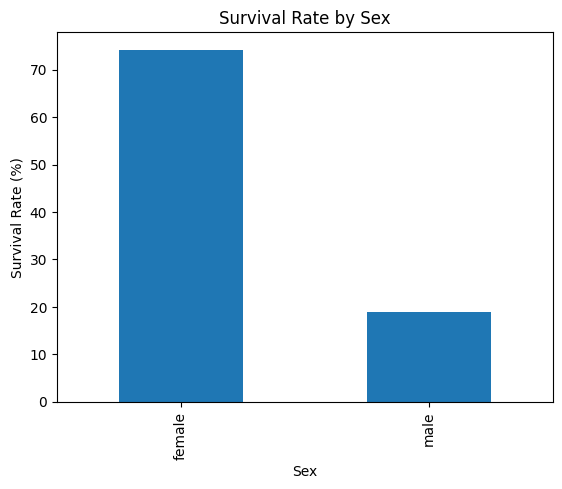

In [383]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

survival_by_sex.plot(
    kind='bar',
    xlabel='Sex',
    ylabel='Survival Rate (%)',
    title='Survival Rate by Sex'
)

**Plot 2: Passenger Class vs Survival Rate**

<Axes: title={'center': 'Survival Rate by Passenger Class'}, xlabel='Passenger Class', ylabel='Survival Rate (%)'>

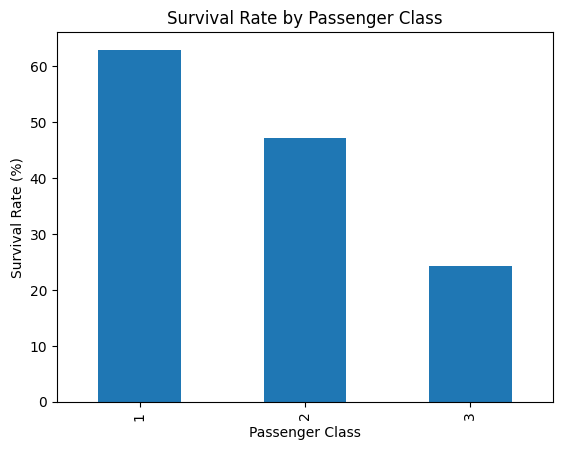

In [384]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100

survival_by_class.plot(
    kind='bar',
    xlabel='Passenger Class',
    ylabel='Survival Rate (%)',
    title='Survival Rate by Passenger Class'
)

**Plot 3: Survival Rate by Sex within each Passenger Class**

<Axes: title={'center': 'Survival Rate by Sex and Passenger Class'}, xlabel='Passenger Class', ylabel='Survival Rate (%)'>

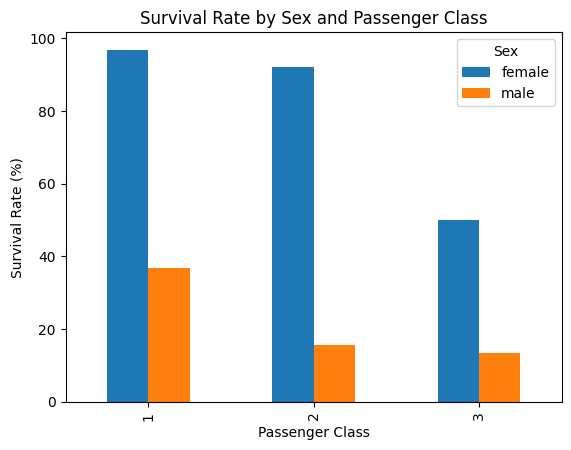

In [385]:
survival_by_class_sex = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100

survival_by_class_sex.plot(
    kind='bar',
    xlabel='Passenger Class',
    ylabel='Survival Rate (%)',
    title='Survival Rate by Sex and Passenger Class'
)

**Plot 4: Fare Distribution by Survival**

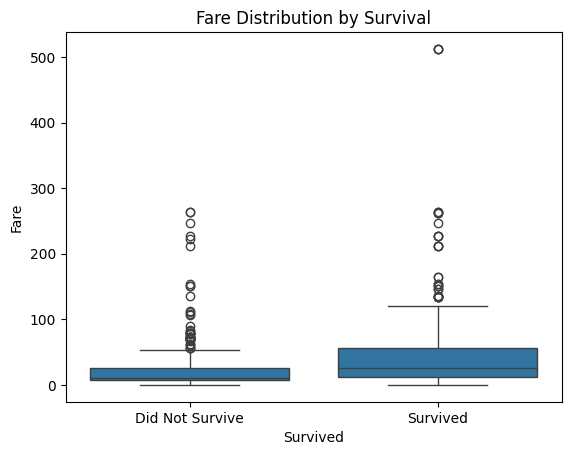

In [386]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Survived', y='Fare', data=df)

plt.xlabel('Survived')
plt.ylabel('Fare')
plt.title('Fare Distribution by Survival')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

In [387]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup',
       'CabinKnown', 'Deck'],
      dtype='object')

In [388]:
df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')[0]
df['TicketGroupSize'] = df.groupby('Ticket')['PassengerId'].transform('count')

In [389]:
df = df.drop(columns=[
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin',
    'AgeGroup',
    'Deck',
    'CabinKnown'
])

In [390]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'TicketGroupSize'],
      dtype='object')

## Feature Engineering — FamilySize

`FamilySize` combines the number of siblings/spouses (`SibSp`) and parents/children (`Parch`) with the passenger themselves:

**FamilySize = SibSp + Parch + 1**

This experiment tests whether representing family relationships as a single feature provides more useful information to the neural network than using `SibSp` and `Parch` separately.

In [391]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [392]:
X=df.drop(columns=['SibSp', 'Parch','Survived'],axis=1)

In [393]:
from sklearn.model_selection import train_test_split


y = df['Survived']

X_train_exp1, X_temp_exp1, y_train_exp1, y_temp_exp1 = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_exp1, X_test_exp1, y_val_exp1, y_test_exp1 = train_test_split(
    X_temp_exp1,
    y_temp_exp1,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_exp1
)

In [394]:
print("Train:", X_train_exp1.shape, y_train_exp1.shape)
print("Validation:", X_val_exp1.shape, y_val_exp1.shape)
print("Test:", X_test_exp1.shape, y_test_exp1.shape)

Train: (623, 8) (623,)
Validation: (134, 8) (134,)
Test: (134, 8) (134,)


In [395]:
X_train_exp1.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'TicketGroupSize',
       'FamilySize'],
      dtype='object')

In [396]:
print("\nSurvival distribution:")

print("\nTrain:")
print(y_train_exp1.value_counts(normalize=True))

print("\nValidation:")
print(y_val_exp1.value_counts(normalize=True))

print("\nTest:")
print(y_test_exp1.value_counts(normalize=True))


Survival distribution:

Train:
Survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64

Validation:
Survived
0    0.61194
1    0.38806
Name: proportion, dtype: float64

Test:
Survived
0    0.619403
1    0.380597
Name: proportion, dtype: float64


In [397]:
age_group_stats = (
    X_train_exp1
    .groupby(['Sex', 'Title'])['Age']
    .agg(['count', 'median'])
    .sort_values('count')
)

age_group_stats

count  median
Sex    Title                  
female Dr            1    49.0
       Lady          1    48.0
male   Don           1    40.0
       Jonkheer      1    38.0
       Major         1    52.0
       Sir           1    49.0
       Col           2    58.0
female Mlle          2    24.0
male   Dr            4    41.0
       Rev           5    51.0
       Master       23     3.0
female Mrs          83    35.0
       Miss        100    21.0
male   Mr          279    30.0

In [398]:
# Median Age by Sex — calculated only from training data
sex_age_medians = X_train_exp1.groupby('Sex')['Age'].median()

# Overall training median — final fallback
overall_age_median = X_train_exp1['Age'].median()

print("Sex-wise medians:")
print(sex_age_medians)

print("\nOverall training median:")
print(overall_age_median)

Sex-wise medians:
Sex
female    28.0
male      30.0
Name: Age, dtype: float64

Overall training median:
29.0


In [399]:
age_group_stats = (
    X_train_exp1
    .groupby(['Sex', 'Title'])['Age']
    .agg(['count', 'median'])
)

reliable_age_medians = age_group_stats[
    age_group_stats['count'] >= 10
]['median']

reliable_age_medians

Sex     Title 
female  Miss      21.0
        Mrs       35.0
male    Master     3.0
        Mr        30.0
Name: median, dtype: float64

In [400]:
def impute_age(data):
    data = data.copy()

    for idx in data.index:
        if pd.isna(data.loc[idx, 'Age']):

            key = (data.loc[idx, 'Sex'], data.loc[idx, 'Title'])

            if key in reliable_age_medians.index:
                data.loc[idx, 'Age'] = reliable_age_medians.loc[key]

            elif data.loc[idx, 'Sex'] in sex_age_medians.index:
                data.loc[idx, 'Age'] = sex_age_medians.loc[data.loc[idx, 'Sex']]

            else:
                data.loc[idx, 'Age'] = overall_age_median

    return data

In [401]:
X_train_exp1 = impute_age(X_train_exp1)
X_val_exp1 = impute_age(X_val_exp1)
X_test_exp1 = impute_age(X_test_exp1)

In [402]:
print("Missing Age:")
print("Train:", X_train_exp1['Age'].isna().sum())
print("Validation:", X_val_exp1['Age'].isna().sum())
print("Test:", X_test_exp1['Age'].isna().sum())

Missing Age:
Train: 0
Validation: 0
Test: 0


In [403]:
embarked_mode = X_train_exp1['Embarked'].mode()[0]

print("Training Embarked mode:", embarked_mode)

Training Embarked mode: S


In [404]:
X_train_exp1['Embarked'] = X_train_exp1['Embarked'].fillna(embarked_mode)
X_val_exp1['Embarked'] = X_val_exp1['Embarked'].fillna(embarked_mode)
X_test_exp1['Embarked'] = X_test_exp1['Embarked'].fillna(embarked_mode)

In [405]:
print("Missing Embarked:")
print("Train:", X_train_exp1['Embarked'].isna().sum())
print("Validation:", X_val_exp1['Embarked'].isna().sum())
print("Test:", X_test_exp1['Embarked'].isna().sum())

Missing Embarked:
Train: 0
Validation: 0
Test: 0


In [406]:
print("Sex:")
print(X_train_exp1['Sex'].unique())

print("\nEmbarked:")
print(X_train_exp1['Embarked'].unique())

print("\nTitle:")
print(X_train_exp1['Title'].value_counts())

Sex:
['male' 'female']

Embarked:
['S' 'Q' 'C']

Title:
Title
Mr          364
Miss        122
Mrs          91
Master       26
Dr            6
Rev           5
Col           2
Mlle          2
Major         1
Lady          1
Jonkheer      1
Don           1
Sir           1
Name: count, dtype: int64


In [407]:
#Keeping all the titles with low frequency in 'Rare' category.
major_titles = ['Mr', 'Miss', 'Mrs', 'Master']

for data in [X_train_exp1, X_val_exp1, X_test_exp1]:
    data['Title'] = data['Title'].where(
        data['Title'].isin(major_titles),
        'Rare'
    )

In [408]:
X_train_exp1['Title'].value_counts()

,count
Title,
Mr,364
Miss,122
Mrs,91
Master,26
Rare,20


In [409]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_cols = [
    'Pclass',
    'Age',
    'FamilySize',
    'Fare',
    'TicketGroupSize'
]

categorical_cols = [
    'Sex',
    'Embarked',
    'Title'
]

In [410]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(
            drop='if_binary',
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_cols)
    ],
    remainder='drop'
)

In [411]:
X_train_processed_exp1 = preprocessor.fit_transform(X_train_exp1)
X_val_processed_exp1 = preprocessor.transform(X_val_exp1)
X_test_processed_exp1 = preprocessor.transform(X_test_exp1)

In [412]:
print("Train shape:", X_train_processed_exp1.shape)
print("Validation shape:", X_val_processed_exp1.shape)
print("Test shape:", X_test_processed_exp1.shape)

Train shape: (623, 14)
Validation shape: (134, 14)
Test shape: (134, 14)


In [413]:
feature_names_exp1 = preprocessor.get_feature_names_out()

print(feature_names_exp1)
print("Total features:", len(feature_names_exp1))

['num__Pclass' 'num__Age' 'num__FamilySize' 'num__Fare'
 'num__TicketGroupSize' 'cat__Sex_male' 'cat__Embarked_C'
 'cat__Embarked_Q' 'cat__Embarked_S' 'cat__Title_Master' 'cat__Title_Miss'
 'cat__Title_Mr' 'cat__Title_Mrs' 'cat__Title_Rare']
Total features: 14


## Model Training

The same neural-network architecture, optimizer, loss function, learning rate, random seed, and train/validation/test split used in the baseline are retained.

The only experimental change is the addition of `FamilySize`.

In [414]:
import torch
import torch.nn as nn
import torch.optim as optim

In [415]:
X_train_tensor = torch.tensor(X_train_processed_exp1, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed_exp1, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed_exp1, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_exp1.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val_exp1.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_exp1.values, dtype=torch.float32).view(-1, 1)

In [416]:
class TitanicNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [417]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [418]:
model = TitanicNN(X_train_processed_exp1.shape[1])

print(model)

TitanicNN(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [419]:
criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [420]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [421]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [422]:
'''X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)'''

'X_batch, y_batch = next(iter(train_loader))\n\nprint("X batch shape:", X_batch.shape)\nprint("y batch shape:", y_batch.shape)'

In [423]:
num_epochs = 100
patience = 10

In [424]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(predictions, y_batch)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    # -------------------------
    # Early stopping
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        patience_counter = 0

        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

    # Print progress
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Epoch [1/100] Train Loss: 0.7013 Val Loss: 0.6834
Epoch [2/100] Train Loss: 0.6746 Val Loss: 0.6525
Epoch [3/100] Train Loss: 0.6409 Val Loss: 0.6145
Epoch [4/100] Train Loss: 0.6025 Val Loss: 0.5730
Epoch [5/100] Train Loss: 0.5564 Val Loss: 0.5323
Epoch [6/100] Train Loss: 0.5225 Val Loss: 0.4968
Epoch [7/100] Train Loss: 0.4859 Val Loss: 0.4628
Epoch [8/100] Train Loss: 0.4555 Val Loss: 0.4299
Epoch [9/100] Train Loss: 0.4306 Val Loss: 0.4083
Epoch [10/100] Train Loss: 0.4172 Val Loss: 0.3947
Epoch [11/100] Train Loss: 0.4151 Val Loss: 0.3885
Epoch [12/100] Train Loss: 0.4000 Val Loss: 0.3819
Epoch [13/100] Train Loss: 0.4030 Val Loss: 0.3774
Epoch [14/100] Train Loss: 0.3989 Val Loss: 0.3755
Epoch [15/100] Train Loss: 0.3891 Val Loss: 0.3728
Epoch [16/100] Train Loss: 0.3812 Val Loss: 0.3697
Epoch [17/100] Train Loss: 0.3834 Val Loss: 0.3687
Epoch [18/100] Train Loss: 0.3809 Val Loss: 0.3652
Epoch [19/100] Train Loss: 0.3768 Val Loss: 0.3633
Epoch [20/100] Train Loss: 0.3715 Val Lo

In [425]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

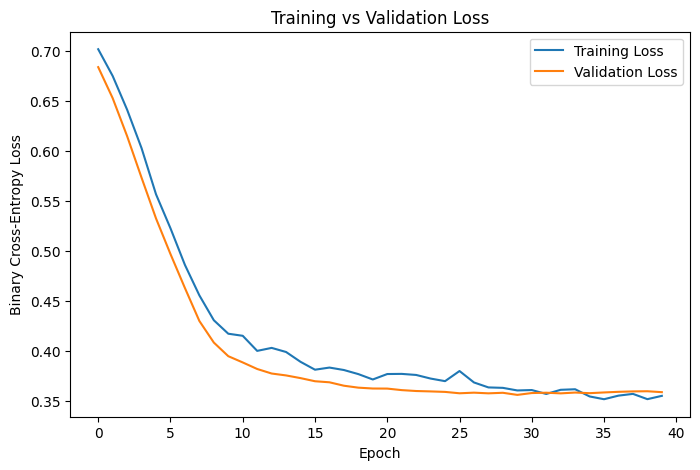

In [426]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

In [427]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

val_probabilities = []
val_actual = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:

        probabilities = model(X_batch)

        val_probabilities.extend(
            probabilities.squeeze().numpy()
        )

        val_actual.extend(
            y_batch.squeeze().numpy()
        )

In [428]:
val_predictions = [
    1 if p >= 0.5 else 0
    for p in val_probabilities
]

In [429]:
val_accuracy = accuracy_score(
    val_actual,
    val_predictions
)

val_precision = precision_score(
    val_actual,
    val_predictions
)

val_recall = recall_score(
    val_actual,
    val_predictions
)

val_f1 = f1_score(
    val_actual,
    val_predictions
)

print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1-score : {val_f1:.4f}")

Accuracy : 0.8657
Precision: 0.8542
Recall   : 0.7885
F1-score : 0.8200


In [430]:
print("\nClassification Report:")
print(
    classification_report(
        val_actual,
        val_predictions,
        target_names=['Did not survive', 'Survived']
    )
)


Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.87      0.91      0.89        82
       Survived       0.85      0.79      0.82        52

       accuracy                           0.87       134
      macro avg       0.86      0.85      0.86       134
   weighted avg       0.87      0.87      0.86       134



In [431]:
cm = confusion_matrix(
    val_actual,
    val_predictions
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[75  7]
 [11 41]]


## Conclusion

Adding `FamilySize` produced a modest improvement over the baseline neural network.

The model achieved:

- **Accuracy:** 86.57%
- **Precision:** 85.42%
- **Recall:** 78.85%
- **F1-score:** 82.00%

The F1-score improved from **80.77%** in the baseline to **82.00%** after introducing `FamilySize`. This indicates that combining `SibSp` and `Parch` into a single family-size feature provides some additional predictive information.

However, the improvement is relatively small, so `FamilySize` alone does not provide a major performance gain. Further feature-engineering experiments are therefore required to determine whether other derived features can provide stronger improvements.